<a href="https://colab.research.google.com/github/gohzhihwee/stuffs/blob/main/Option_Pricing_Workbook_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss
from scipy.stats import lognorm, norm

In [ ]:
def bs_call_price(S, r, sigma, t, T, K):
  ttm = T - t

  if ttm < 0:
    return 0.0
  elif ttm == 0.0:
    return np.maximum(S-K, 0.0)

  vol = sigma*np.sqrt(ttm)

  d_minus = np.log(S/K) + (r-0.5*sigma**2)*ttm
  d_minus /= vol

  d_plus = d_minus + vol

  res = S*norm.cdf(d_plus)
  res -= K*np.exp(-r*ttm)*norm.cdf(d_minus)

  return res

In [ ]:
def bs_put_price(S, r, sigma, t, T, K):
  ttm = T - t

  if ttm < 0:
    return 0.0
  elif ttm == 0.0:
    return np.maximum(K-S, 0.0)

  vol = sigma*np.sqrt(ttm)

  d_minus = np.log(S/K) + (r-0.5*sigma**2)*ttm
  d_minus /= vol

  d_plus = d_minus + vol

  res = S*norm.cdf(d_plus)
  res -= K*np.exp(-r*ttm)*norm.cdf(d_minus)

  return res

In [ ]:
def american_option(S_ini, K, T, r, u, d, N, opttype):
  dt = T/N
  p = (np.exp(r*dt) - d)/(u - d)
  C = np.zeros([N + 1, N + 1])
  S = np.zeros([N + 1, N + 1])
  Delta = np.zeros([N, N])
  for i in range(0, N + 1):
    S[N, i] = S_ini * (u**i) * (d**(N - i))
    if opttype == "C":
      C[N, i] = max(S[N, i] - K, 0)
    elif opttype == "P":
      C[N, i] = max(K - S[N, i], 0)
  for j in range(N-1, -1, -1):
    for i in range(0, j + 1):
      C[j, i] = np.exp(-r*dt) * (p * C[j+1, i+1] + (1 - p) * C[j+1, i])
      S[j, i] = S_ini * (u**i) * (d**(j - i))
      if opttype == "C":
        C[j, i] = max(C[j, i], S[j, i] - K)
      elif opttype == "P":
        C[j, i] = max(K - S[j, i], C[j, i])
      Delta[j, i] = (C[j+1, i+1] - C[j+1, i])/(S[j+1, i+1] - S[j+1, i])
  return C[0,0], C, S, Delta

In [ ]:
def european_option(S_ini, K, T, r, u, d, N, opttype):
  dt = T/N
  p = (np.exp(r*dt) - d)/(u - d)
  C = np.zeros([N + 1, N + 1])
  S = np.zeros([N + 1, N + 1])
  Delta = np.zeros([N, N])
  for i in range(0, N + 1):
    S[N, i] = S_ini * (u**i) * (d**(N - i))
    if opttype == "C":
      C[N, i] = max(S[N, i] - K, 0)
    elif opttype == "P":
      C[N, i] = max(K - S[N, i], 0)
  for j in range(N-1, -1, -1):
    for i in range(0, j + 1):
      C[j, i] = np.exp(-r*dt) * (p * C[j+1, i+1] + (1 - p) * C[j+1, i])
      S[j, i] = S_ini * (u**i) * (d**(j - i))
      Delta[j, i] = (C[j+1, i+1] - C[j+1, i])/(S[j+1, i+1] - S[j+1, i])
  return C[0, 0], C, S, Delta

In [ ]:
print(bs_call_price(100.0, 0.0, 0.2, 0, 2.0, 105.0))

9.19735064929452


# **Step 1**

**Questions 1 and 2: Using Black-Scholes Closed-Form Solution and Monte Carlo Methods to Compute the Option Price, Delta and Vega**

We calculate the price of European Options using the closed-form solution to the Black-Scholes model, as well as their Deltas and Vegas. We assume the option values and parameters given to us in GWP #1 – the options have an initial underlying stock price of 100, a risk-free rate of 0.05, a volatility of 0.2 and a time to maturity of 3 months. We assume ATM conditions (i.e. strike price is equal to the initial underlying stock price). Using Black-Scholes closed form solution, we can calculate the Deltas and Vegas directly.

In [ ]:
def bs_call_mc(S, K, r, sigma, T, t, Ite):
  data = np.zeros((Ite, 2))
  z = np.random.normal(0, 1, [1, Ite])
  ST = S*np.exp((T - t)*(r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
  data[:, 1] = ST - K
  print(data)

  average = np.sum(np.amax(data, axis=1)) / float(Ite)

  return np.exp(-r * (T - t)) * average

In [ ]:
def bs_put_mc(S, K, r, sigma, T, t, Ite):
  data = np.zeros((Ite, 2))
  z = np.random.normal(0, 1, [1, Ite])
  ST = S*np.exp((T - t)*(r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
  data[:, 1] = K - ST

  average = np.sum(np.amax(data, axis=1)) / float(Ite)

  return np.exp(-r * (T - t)) * average

Below we display the European call option price, calculated as an average of 100000 Monte Carlo simulations:

In [ ]:
print("Monte Carlo Price:", bs_call_mc(100, 95, 0.06, 0.3, 1, 0, 100000))

[[  0.          -4.36547807]
 [  0.         -33.98357838]
 [  0.          43.94233238]
 ...
 [  0.         -20.43721254]
 [  0.          29.58804928]
 [  0.          64.06814891]]
Monte Carlo Price: 17.231885529803268


... and below we display the same option price, calculated using the Black-Scholes closed form solution:

In [ ]:
# BS - European Calls
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = S_ini
europrice_c = bs_call_price(S_ini, r, sigma, t, T, K)
print(europrice_c)

20.924360952895213


We note a difference of ~$3.57 in the prices calculated between the two methods. In the following 3 cells, we proceed to use the Black-Scholes model to calculate the prices, deltas and vegas for the European calls and puts.

In [ ]:
# BS - European Calls - Calculating the Vega
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = S_ini
option_type = "C"

d1 = (np.log(S_ini / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

if option_type in ["C", "P"]:
  if option_type == "C":
    Opt_Price = S_ini * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    Delta = norm.cdf(d1)
    Gamma = norm.pdf(d1) / (S_ini * sigma * np.sqrt(T))
    Vega = S_ini * np.sqrt(T) * norm.pdf(d1)
    Theta = -(S_ini * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    Rho = K * T * np.exp(-r * T) * norm.cdf(d2)
  else:
    Opt_Price = K * np.exp(-r * T) * norm.cdf(-d2) - S_ini * norm.cdf(-d1)
    Delta = -norm.cdf(-d1)
    Gamma = norm.pdf(d1) / (S_ini * sigma * np.sqrt(T))
    Vega = norm.pdf(d1) * S_ini * np.sqrt(T)
    Theta = -(S_ini * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    Rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
else:
  Opt_Price = 'Error: option type incorrect. Choose P for a put option or C for a call option.'

print("Option price = {}".format(Opt_Price))
print("Delta = {}".format(Delta))
print("Gamma = {}".format(Gamma))
print("Vega = {}".format(Vega))
print("Theta = {}".format(Theta))
print("Rho = {}".format(Rho))

Option price = 20.924360952895213
Delta = 0.7278149270716952
Gamma = 0.009583360639299687
Vega = 57.50016383579811
Theta = -4.509528715573652
Rho = 155.5713952628229


In [ ]:
# BS - European Puts
europrice_p = bs_put_price(S_ini, r, sigma, t, T, K)
print(europrice_p)

20.924360952895213


In [ ]:
# BS - European Puts - Calculating the Vega
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = S_ini
option_type = "P"

d1 = (np.log(S_ini / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

if option_type in ["C", "P"]:
  if option_type == "C":
    Opt_Price = S_ini * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    Delta = norm.cdf(d1)
    Gamma = norm.pdf(d1) / (S_ini * sigma * np.sqrt(T))
    Vega = S_ini * np.sqrt(T) * norm.pdf(d1)
    Theta = -(S_ini * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    Rho = K * T * np.exp(-r * T) * norm.cdf(d2)
  else:
    Opt_Price = K * np.exp(-r * T) * norm.cdf(-d2) - S_ini * norm.cdf(-d1)
    Delta = -norm.cdf(-d1)
    Gamma = norm.pdf(d1) / (S_ini * sigma * np.sqrt(T))
    Vega = norm.pdf(d1) * S_ini * np.sqrt(T)
    Theta = -(S_ini * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    Rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
else:
  Opt_Price = 'Error: option type incorrect. Choose P for a put option or C for a call option.'

print("Option price = {}".format(Opt_Price))
print("Delta = {}".format(Delta))
print("Gamma = {}".format(Gamma))
print("Vega = {}".format(Vega))
print("Theta = {}".format(Theta))
print("Rho = {}".format(Rho))

Option price = 6.995158595400991
Delta = -0.27218507292830485
Gamma = 0.009583360639299687
Vega = 57.50016383579811
Theta = -0.2059888334483635
Rho = -102.64099766469441


We now switch to using Monte Carlo simulation methods, choosing to simulate over 100000 iterations. Once we switch to Monte Carlo methods, knowing that vega measures the change in option price given a percentage point (1%) change in volatility, we divide the change in option price by the percentage change in the volatility to yield the proxy for vega, an alternative to the traditional mathematical formula for vega. We revert to the binomial tree pricing method (with N = 3 steps) to calculate delta.

In [ ]:
# MC - European Calls
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = S_ini
europrice_c_mc = bs_call_mc(S_ini, K, r, sigma, T, t, 100000)
print(europrice_c_mc)

[[  0.          89.04580012]
 [  0.          15.1026425 ]
 [  0.         -13.90534987]
 ...
 [  0.           2.28912065]
 [  0.         -29.85066195]
 [  0.          51.5922282 ]]
20.74548866042364


In [ ]:
N = 3
dt = T/N
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
price_euro_c, C_euro_c, S_euro_c, delta_euro_c = european_option(S_ini, K, T, r, u, d, N, "C")
print(delta_euro_c)

[[0.69295563 0.         0.        ]
 [0.36891187 0.85187349 0.        ]
 [0.         0.549834   1.        ]]


In [ ]:
europrice_c_mc_2 = bs_call_mc(S_ini, K, r, sigma*4, T, t, 1000000)

[[  0.          12.13771548]
 [  0.         959.04511216]
 [  0.         -89.78008443]
 ...
 [  0.         -87.27601249]
 [  0.         -50.98240195]
 [  0.         -72.99578643]]


In [ ]:
vega = (europrice_c_mc_2 - europrice_c_mc)/400
print(vega)

0.086511924876442


In [ ]:
europrice_p_mc = bs_put_mc(S_ini, K, r, sigma, T, t, 100000)
print(europrice_p_mc)

7.062982751858624


In [ ]:
price_euro_p, C_euro_p, S_euro_p, delta_euro_p = european_option(S_ini, K, T, r, u, d, N, "P")
print(delta_euro_p)

[[-0.30704437  0.          0.        ]
 [-0.63108813 -0.14812651  0.        ]
 [-1.         -0.450166    0.        ]]


In [ ]:
europrice_p_mc_2 = bs_put_mc(S_ini, K, r, sigma*4, T, t, 1000000)

In [ ]:
# Alternative to traditional vega formula as vega = difference in price change for 1% change in volatility
vega = (europrice_p_mc_2 - europrice_p_mc)/400
print(vega)

0.0844040936574273


**Question 3: Checking for Put-Call Parity**

Here we check for the satisfaction of Put-Call parity and compare the prices of the options obtained using the Black-Scholes and Monte Carlo methods. We recall the equation expressing put-call parity which is given by

$c_0 + Ke^{-rT} = S_0 + p_0$

and substituting the values of the call and put options obtained via Black-Scholes model into the equation gets us

$LHS: 20.92 + 100e^{-0.05(3)} = 106.99$

$RHS: 100 + 6.99 = 1006.99$

from which we can see that put-call parity holds. Substituting the values of the call and put options obtained via Monte Carlo simulation yields

$LHS: 21.05 + 100e^{-0.05(3)} = 107.12$

$RHS: 100 + 7.05 = 107.05$

from which we can also infer the general satisfaction of put-call parity with a margin of rounding and error.

*Do the prices calculated by the Black-Scholes closed-form solution and Monte Carlo methods converge?*

We observe that over a large number (> 1000) of Monte Carlo simulations, the values obtained in each simulation fluctuate around the average over all simulations by slightly more or less. The average value is close to the value obtained via the Black-Scholes model and will eventually converge with it as the number of simulations approaches infinity, given that Monte Carlo involves running the option price calculation for many iterations.

# **Step 2**

**Question 4: Calculating the Price of American Options (Monte Carlo)**

We use Monte Carlo simulations to calculate the price of American options, simulating over 100000 iterations and assuming the same initial option values and parameters as in the previous 3 questions.

In [ ]:
def bs_call_mc_am(S, K, r, sigma, T, t, Ite):
  data = np.zeros((Ite, 2))
  z = np.random.normal(0, 1, [1, Ite])
  ST = S*np.exp((T - t)*(r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
  # data[:, 1] = ST - K # Keeping European Option Price for Comparison
  for i in range(ST.shape[0]):
    for j in range(ST.shape[1]-2, -1, -1):
      if ST[i, j] > ST[i, j+1] - K:
        data[j+1, i] = ST[i, j]
      else:
        data[j+1, i] = ST[i, j+1] - K

  average = np.sum(np.amax(data, axis=1)) / float(Ite)

  return np.exp(-r * (T - t)) * average

In [ ]:
def bs_put_mc_am(S, K, r, sigma, T, t, Ite):
  data = np.zeros((Ite, 2))
  z = np.random.normal(0, 1, [1, Ite])
  ST = S*np.exp((T - t)*(r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
  # data[:, 1] = K - ST # Keeping European Option Price for Comparison
  for i in range(ST.shape[0]):
    for j in range(ST.shape[1]-2, -1, -1):
      if ST[i, j] > K - ST[i, j+1]:
        data[j+1, i] = ST[i, j]
      else:
        data[j+1, i] = K - ST[i, j+1]

  average = np.sum(np.amax(data, axis=1)) / float(Ite)

  return np.exp(-r * (T - t)) * average

**Question 5: Calculating Delta and Vega of the American Options**

Here we use the binomial tree pricing method to calculate delta and our alternate formula as defined in question (2) for calculating a proxy vega.

In [ ]:
# MC - American Calls
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = S_ini
amprice_c_mc_atm = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_c_mc_atm)

101.17391296715172


In [ ]:
amprice_c_mc_2 = bs_call_mc_am(S_ini, K, r, sigma*4, T, t, 1000000)
print(amprice_c_mc_2)

141.56758741055597


In [ ]:
N = 3
dt = T/N
u, d = np.exp(sigma*np.sqrt(dt)), np.exp(-sigma*np.sqrt(dt))
price_american_c, C_american_c, S_american_c, delta_american_c = american_option(S_ini, K, T, r, u, d, N, "C")
print(delta_american_c)

[[0.69295563 0.         0.        ]
 [0.36891187 0.85187349 0.        ]
 [0.         0.549834   1.        ]]


In [ ]:
vega_am = (amprice_c_mc_2 - amprice_c_mc_atm)/400
print(vega_am)

0.10098418610851062


In [ ]:
# MC - American Puts
amprice_p_mc_atm = bs_put_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_p_mc_atm)

99.9526112656198


In [ ]:
amprice_p_mc_2 = bs_put_mc_am(S_ini, K, r, sigma*4, T, t, 1000000)
print(amprice_p_mc_2)

116.23433284708395


In [ ]:
price_american_p, C_american_p, S_american_p, delta_american_p = american_option(S_ini, K, T, r, u, d, N, "P")
print(delta_american_p)

[[-0.37745324  0.          0.        ]
 [-0.77902122 -0.14812651  0.        ]
 [-1.         -0.450166    0.        ]]


In [ ]:
vega_am = (amprice_p_mc_2 - amprice_p_mc_atm)/400
print(vega_am)

0.040704303953660384


**Question 6: 5 Cases of Moneyness (Deep OTM, OTM, ATM, ITM, Deep ITM)**

We now repeat the 5 cases of moneyness (deep OTM, OTM, ATM, ITM and deep ITM) for American option prices using Monte Carlo simulations. Respectively, the 5 cases of moneyness occur when the strike price is 90% of, 95% of, 100% of, 105% of and 110% of the initial underlying stock price. Subsequently, we plot the American option prices with the level of moneyness.

In [ ]:
# 5 Strike Prices - MC (American Options)
call_prices, put_prices, moneyness = [], [], []
# Calls
# Deep OTM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 0.9*S_ini
amprice_c_mc = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_c_mc)
call_prices.append(amprice_c_mc)
moneyness.append(K/S_ini)

101.68577525323786


In [ ]:
# Calls
# OTM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 0.95*S_ini
amprice_c_mc = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_c_mc)
call_prices.append(amprice_c_mc)
call_prices.append(amprice_c_mc_atm)
moneyness.append(K/S_ini)
moneyness.append(1)

101.37651271817847


In [ ]:
# Calls
# ITM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 1.05*S_ini
amprice_c_mc = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_c_mc)
call_prices.append(amprice_c_mc)
moneyness.append(K/S_ini)

101.1612996805432


In [ ]:
# Calls
# Deep ITM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 1.1*S_ini
amprice_c_mc = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_c_mc)
call_prices.append(amprice_c_mc)
moneyness.append(K/S_ini)

100.92265795275944


In [ ]:
# Puts
# Deep OTM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 0.9*S_ini
amprice_p_mc = bs_put_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_p_mc)
put_prices.append(amprice_p_mc)

100.05677502356325


In [ ]:
# Puts
# OTM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 0.95*S_ini
amprice_p_mc = bs_put_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_p_mc)
put_prices.append(amprice_p_mc)
put_prices.append(amprice_p_mc_atm)

99.94241476611113


In [ ]:
# Puts
# ITM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 1.05*S_ini
amprice_p_mc = bs_put_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_p_mc)
put_prices.append(amprice_p_mc)

100.06100010027203


In [ ]:
# Puts
# Deep ITM
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 1.1*S_ini
amprice_p_mc = bs_put_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_p_mc)
put_prices.append(amprice_p_mc)

99.81648810928232


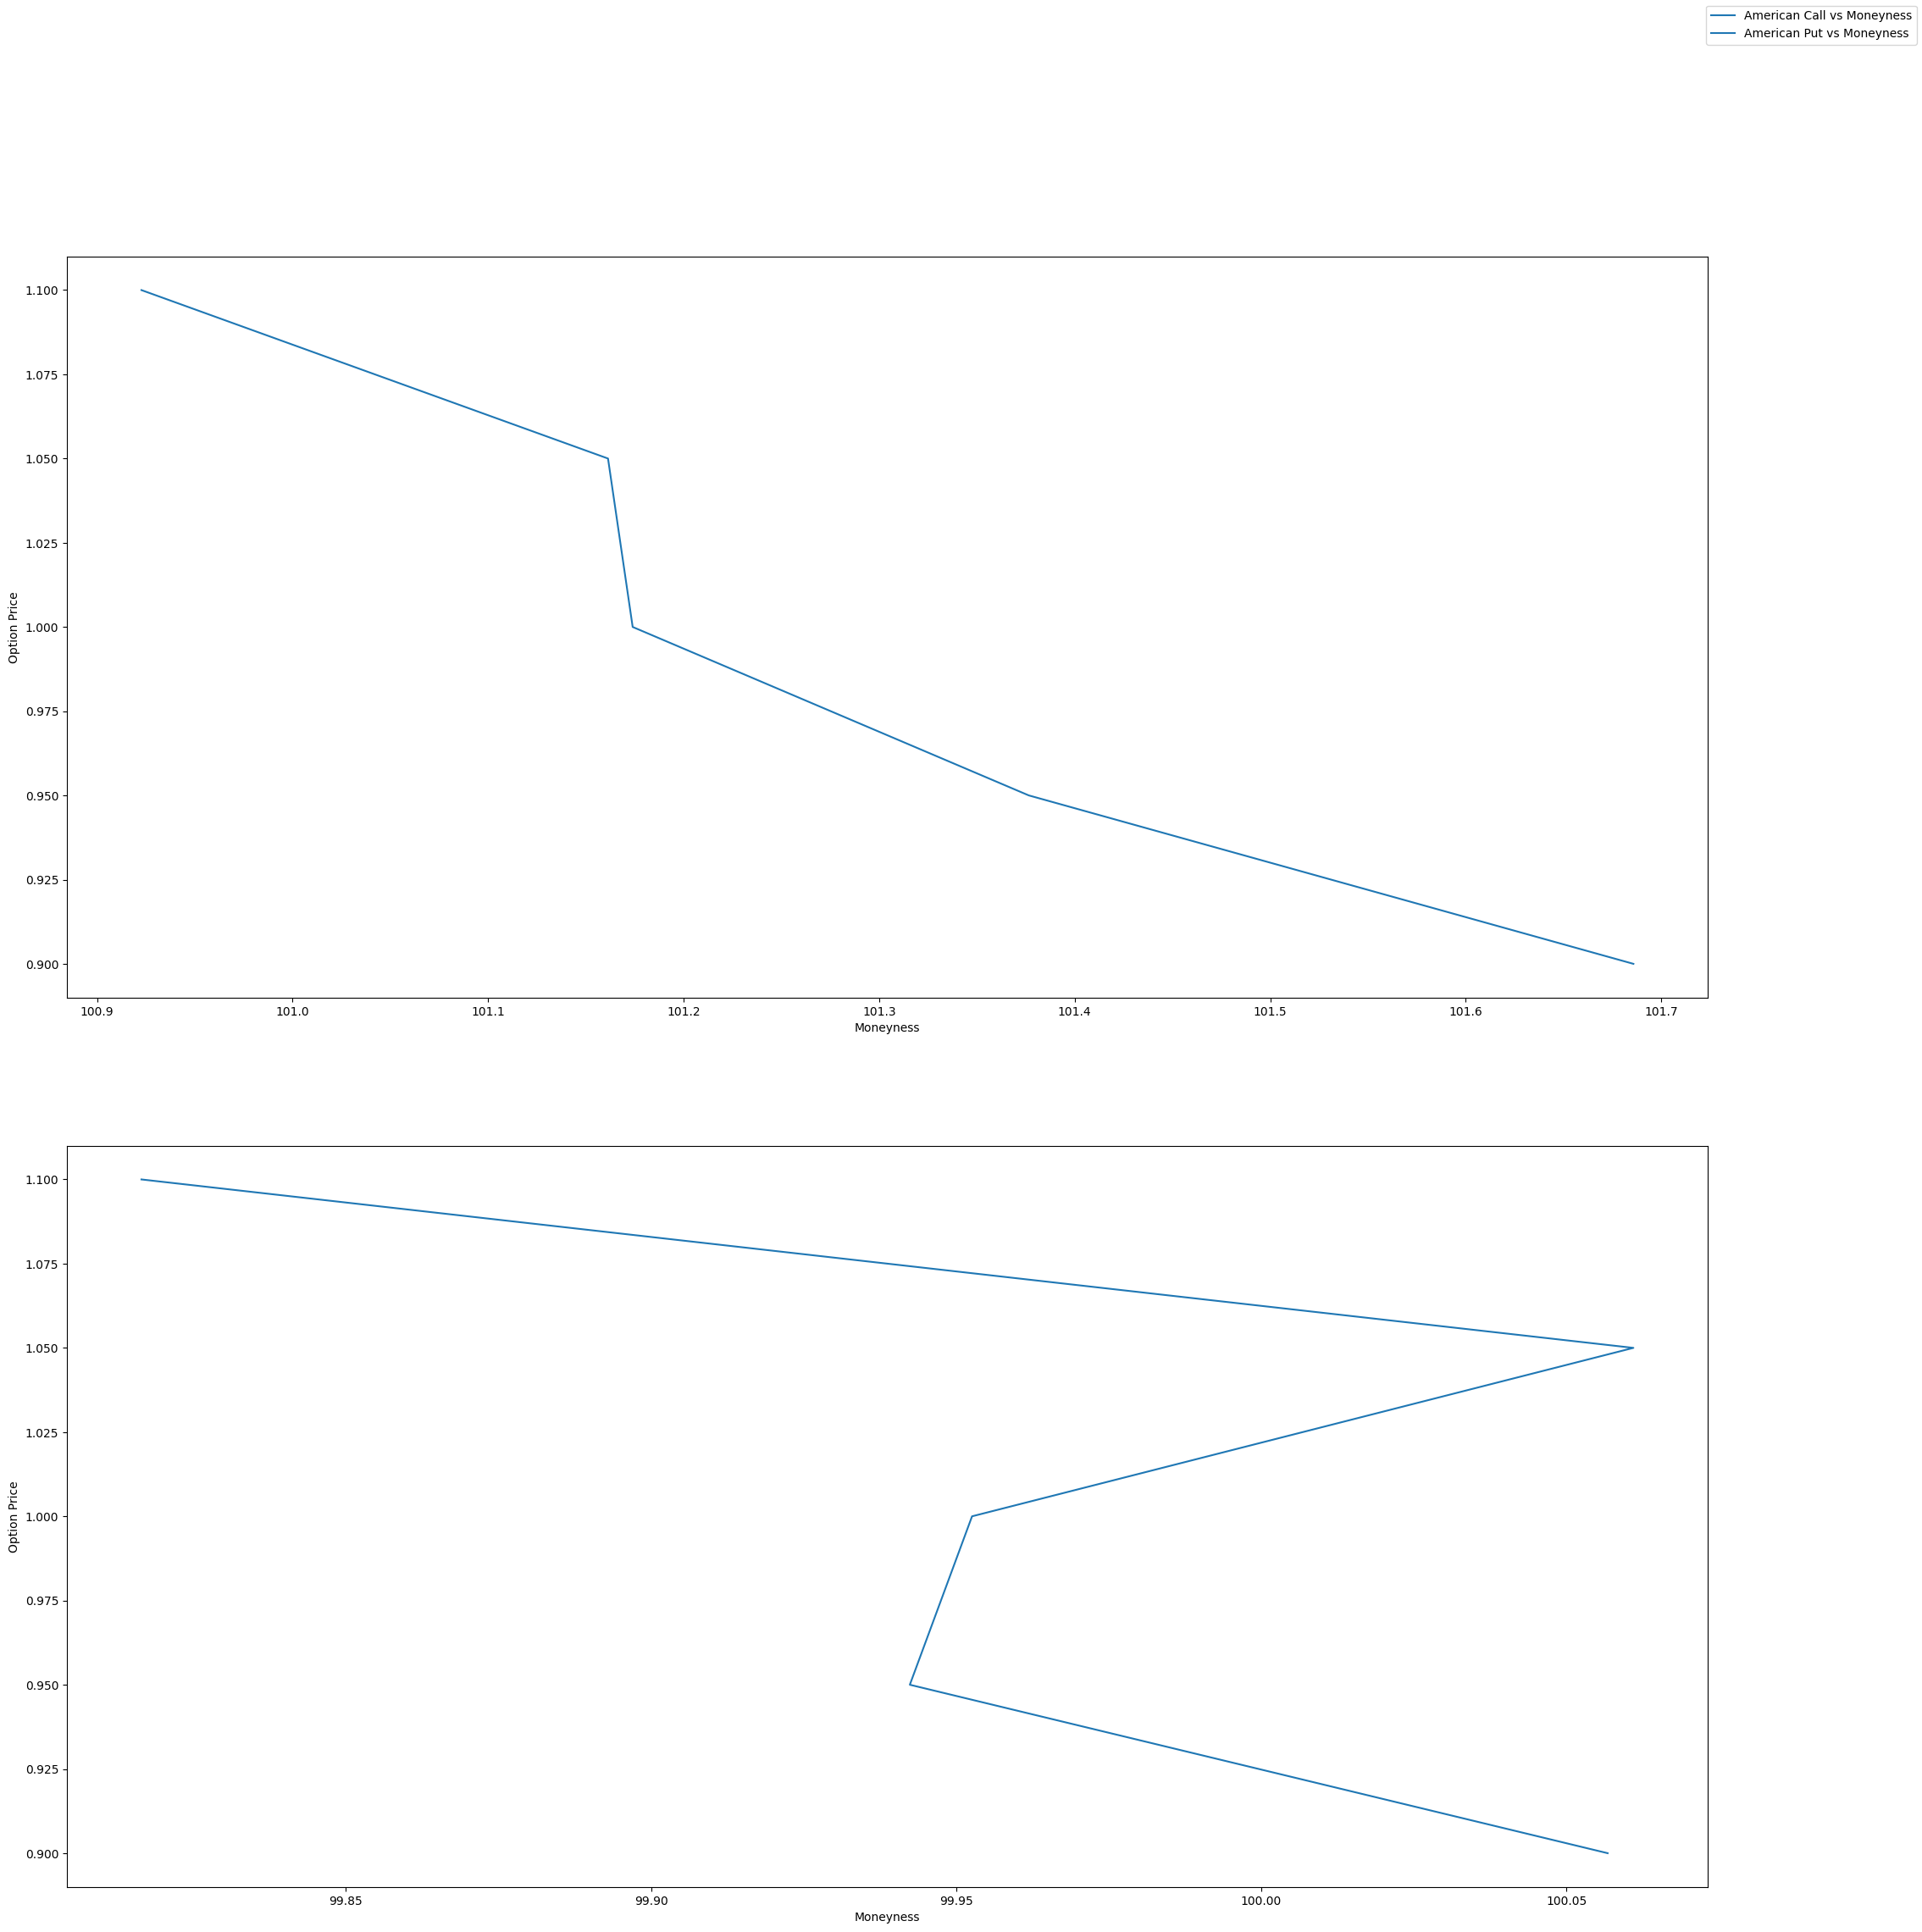

In [ ]:
# Plotting American Options vs Moneyness
fig, ax = plt.subplots(2, figsize=(25,25))
ax[0].plot(call_prices, moneyness, label="American Call vs Moneyness")
ax[1].plot(put_prices, moneyness, label="American Put vs Moneyness")
for a in ax.flat:
    a.set(xlabel='Moneyness', ylabel='Option Price')
fig.legend()
plt.savefig("amer_opt_vs_my.png")
plt.show()

# **Step 3**

**Question 7: Using Black-Scholes to Price 2 European Options at 110% and 95% Moneyness**

In [ ]:
# BS - European Calls - 110% Moneyness
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 1.1*S_ini
europrice_c = bs_call_price(S_ini, r, sigma, t, T, K)
print(europrice_c)

16.210871364283975


In [ ]:
# BS - European Puts - 95% Moneyness
S_ini = 100
r = 0.05
T = 3
t = 0
sigma = 0.2
K = 0.95*S_ini
europrice_p = bs_put_price(S_ini, r, sigma, t, T, K)
print(europrice_p)

23.637301073984503


*Calculating Upward/Downward Movement Scales, Delta and Delta-Hedging Strategy*

To calculate the scale of the upward and downward movements in the underlying stock price, we assume identical initial option values and parameters as given to us in GWP #1 in calculating the deltas. If the portfolio holds both the call and put options, assuming a 1-step binomial tree, the ratio of the stock after upward movement to the initial stock price is

$u = e^{0.02\sqrt{3}} = 1.04$

while the ratio of the stock after downward movement to the initial stock price is

$d = e^{-0.02\sqrt{3}} = 0.966$

We therefore get a for the call option a payoff of 1.04(100) - 110 < 0 in the case of upward movement and 0.966(100) – 110 < 0 in the case of downward movement, thus an overall payoff of 0. For the put option, we obtain a payoff of 95 – 1.04(100) < 0 in the case of upward movement and a payoff of 95 – 0.966(100) < 0 in the case of downward movement, thus an overall payoff of 0. In both cases, the delta of the portfolio is 0 – both options will be ATM in the case of upward and downward movement of the stock and will therefore expire worthless. No amount of delta hedging will enable this portfolio to net a positive payoff.

In the case that the put option is sold, the call option still has a delta of 0. The portfolio contains a call option that will expire worthless and no amount of delta hedging will enable it to net a positive payoff.

**Question 8: Up-and-Out (UAO) Option**

An Up-and-Out (UAO) option is an option that expires worthless if the option price exceeds a set amount, i.e. the barrier amount (Mitchell, 2023). In this case, the initial underlying stock price is $120, the risk-free rate is 0.06, the volatility is 0.3 and the option is ATM (100% moneyness).

In [ ]:
# Quantities for Calculating Delta, Deltas for Calls and Puts
u, d = np.exp(sigma*np.sqrt(T-t)), np.exp(-sigma*np.sqrt(T-t))
payoff_c_u = u*S_ini - K
payoff_c_d = d*S_ini - K
payoff_p_u = K - d*S_ini
payoff_p_d = K - u*S_ini
delta_c = (payoff_c_u - payoff_c_d)/(S_ini*u - S_ini*d)
delta_p = (payoff_p_u - payoff_p_d)/(S_ini*u - S_ini*d)
print(payoff_c_u)
print(payoff_c_d)
print(payoff_p_u)
print(payoff_p_d)
print(delta_c)
print(delta_p)

46.39824580805163
-24.27776477810751
24.27776477810751
-46.39824580805163
1.0
1.0


In [ ]:
# UAO Option - American Call
S_ini = 120
r = 0.06
T = 8
t = 0
sigma = 0.3
K = S_ini
amprice_uao_c = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
if amprice_uao_c > 141:
  amprice_uao_c = 0
print(amprice_uao_c)

0


Given these initial option values and parameters, 100000 iterations of Monte Carlo simulations put the UAO call at a price greater than the barrier amount of \$141, and so the option expires worthless (its price is \$0).

**Question 9: Up-and-In (UAI) Option**

We repeat the same calculations for an Up-and-In (UAI) option and a vanilla option. A UAI option expires worthless if the option price is lower than a set barrier amount (Scott, 2022).

In [ ]:
# UAI Option - American Call
S_ini = 120
r = 0.06
T = 8
t = 0
sigma = 0.3
K = S_ini
amprice_uai_c = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
if amprice_uai_c < 141:
  amprice_uai_c = 0
print(amprice_uai_c)

149.07418245045895


Repeating the Monte Carlo simulations conducted in question (8) with the call option, we obtain a call option price of \$146.92, which exceeds the barrier amount of \$141.

In [ ]:
# Vanilla - American Call
S_ini = 120
r = 0.06
T = 8
t = 0
sigma = 0.3
K = S_ini
amprice_van_c = bs_call_mc_am(S_ini, K, r, sigma, T, t, 100000)
print(amprice_van_c)

147.78826755695965


Repeating the Monte Carlo simulations with the vanilla call, we obtain a price of \$148.31, slightly greater than the UAI option.

*Hedging with the UAO, UAI and Vanilla Options*

A portfolio can be hedged with a combination of these 3 types of options – in the event of potential upward movement in the underlying stock price where the worth of put options are expected to decrease, a UAI option is expected to expire worthless while the price of the vanilla option decreases. In this case, the UAO option retains its value, so it can be used to hedge against the decrease in price of the other two options. Likewise, in the event of downward movement where UAO options expire worthless, the vanilla option and the UAI options stand to increase in price, so they can be used to hedge against losses to the portfolio incurred by the UAO expiring worthless. In the case of highly volatile conditions where the direction of movement is uncertain, both UAI and UAO options can be used to hedge against fluctuations in vanilla options which result in losses to the portfolio.

**Table of Values for Option Prices (Calculated in Questions 5 and 9)**

In [ ]:
import pandas as pd
options_df = pd.DataFrame({
    "Type": ["ATM Call", "ATM Put", "ATM Call", "ATM Put"],
    "Exer": ["Eur", "Eur", "Amer", "Amer"],
    "GWP1 Method": ["Binomial", "Binomial", "Binomial", "Binomial"],
    "GWP2 Method": ["BS", "BS", "MC", "MC"],
    "GWP1 Price": [21.68, 7.75, 21.68, 8.89],
    "GWP2 Price": [europrice_c_mc, europrice_p_mc, amprice_c_mc, amprice_p_mc],
    "% Diff": [(abs(europrice_c_mc - 21.68)/21.68) * 100, (abs(europrice_p_mc - 7.75)/7.75) * 100, (abs(amprice_c_mc - 21.68)/21.68) * 100, (abs(amprice_p_mc - 8.89)/8.89) * 100]
})
options_df.style \
  .format(precision=3, thousands=".", decimal=",") \
  .format_index(str.upper, axis=1) \
  .relabel_index(["5", "5", "8", "8"], axis=0)

,TYPE,EXER,GWP1 METHOD,GWP2 METHOD,GWP1 PRICE,GWP2 PRICE,% DIFF
5,ATM Call,Eur,Binomial,BS,"21,680","20,745","4,310"
5,ATM Put,Eur,Binomial,BS,"7,750","7,063","8,865"
8,ATM Call,Amer,Binomial,MC,"21,680","100,923","365,510"
8,ATM Put,Amer,Binomial,MC,"8,890","99,816","1.022,795"


# **References**

WorldQuant University. (2024, July 23). MScFE620: Derivative Pricing (Modules 1-4).

Mitchell, C. (2023, May 1). Up-and-Out Option: What it is, How it Works, Example. Retrieved from Investopedia: https://www.investopedia.com/terms/u/up-and-outoption.asp

Scott, G. (2022, May 29). Down-and-Out Option: What it is, How it Works. Retrieved from Investopedia: https://www.investopedia.com/terms/d/daoo.asp

